In [1]:
import os

data_dir = r"C:\Users\yadhu\Desktop\chess-piece\data\raw"
print("=== CLASS AUDIT ===\n")
total = 0
for cls in sorted(os.listdir(data_dir)):
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        total += count
        print(f"{cls:30s}: {count} images")

print(f"\nTotal images: {total}")
print(f"Total classes: {len([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])}")

=== CLASS AUDIT ===

bishop                        : 67 images
king                          : 34 images
knight                        : 71 images
pawn                          : 239 images
queen                         : 34 images
rook                          : 72 images

Total images: 517
Total classes: 6


In [2]:
import cv2
import numpy as np
from pathlib import Path

INPUT_DIR  = r"C:\Users\yadhu\Desktop\chess-piece\data\raw"
OUTPUT_DIR = r"C:\Users\yadhu\Desktop\chess-piece\processed"

def detect_color(img_gray):
    h, w = img_gray.shape
    center = img_gray[h//4 : 3*h//4, w//4 : 3*w//4]
    avg_brightness = np.mean(center)
    return "w" if avg_brightness > 127 else "b"

def split_into_12_classes():
    input_path  = Path(INPUT_DIR)
    output_path = Path(OUTPUT_DIR)
    output_path.mkdir(parents=True, exist_ok=True)

    classes = [d for d in input_path.iterdir() if d.is_dir()]
    counts = {}

    for cls_dir in classes:
        piece_name = cls_dir.name.lower()
        images = list(cls_dir.glob("*.jpg")) + \
                 list(cls_dir.glob("*.jpeg")) + \
                 list(cls_dir.glob("*.png"))

        print(f"Processing '{piece_name}': {len(images)} images...")

        for img_path in images:
            img = cv2.imread(str(img_path))
            if img is None:
                continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray_resized = cv2.resize(gray, (64, 64))

            color    = detect_color(gray_resized)
            new_class = f"{color}_{piece_name}"

            out_dir = output_path / new_class
            out_dir.mkdir(exist_ok=True)

            clahe      = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            normalized = clahe.apply(gray_resized)

            out_path = out_dir / img_path.name
            cv2.imwrite(str(out_path), normalized)

            counts[new_class] = counts.get(new_class, 0) + 1

    print("\n=== OUTPUT CLASS COUNTS ===\n")
    for cls, count in sorted(counts.items()):
        print(f"{cls:20s}: {count} images")
    print(f"\nTotal: {sum(counts.values())} images across {len(counts)} classes")

if __name__ == "__main__":
    split_into_12_classes()

Processing 'bishop': 67 images...
Processing 'king': 34 images...
Processing 'knight': 71 images...
Processing 'pawn': 239 images...
Processing 'queen': 34 images...
Processing 'rook': 72 images...

=== OUTPUT CLASS COUNTS ===

b_bishop            : 33 images
b_king              : 18 images
b_knight            : 36 images
b_pawn              : 99 images
b_queen             : 17 images
b_rook              : 37 images
w_bishop            : 34 images
w_king              : 16 images
w_knight            : 35 images
w_pawn              : 140 images
w_queen             : 17 images
w_rook              : 35 images

Total: 517 images across 12 classes


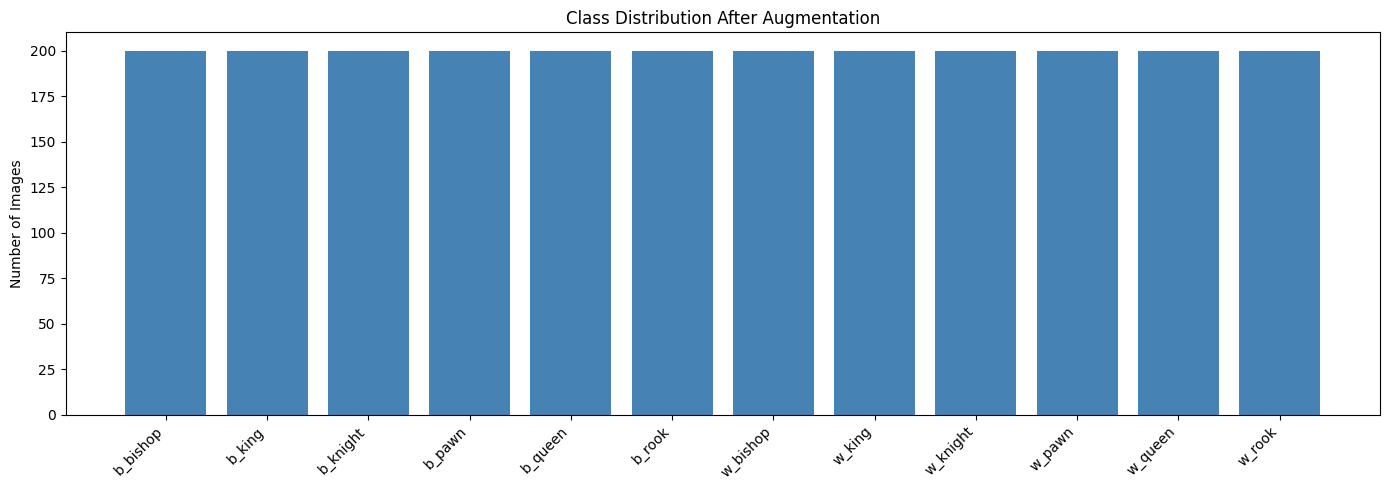

Saved class_distribution.png


In [3]:
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np

processed_dir = r"C:\Users\yadhu\Desktop\chess-piece\processed"
output_dir = r"C:\Users\yadhu\Desktop\chess-piece\data"
os.makedirs(output_dir, exist_ok=True)

classes = sorted(os.listdir(processed_dir))

# 1. Class distribution bar chart
counts = [len(os.listdir(os.path.join(processed_dir, c))) for c in classes]

plt.figure(figsize=(14, 5))
bars = plt.bar(classes, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution After Augmentation")
plt.ylabel("Number of Images")
plt.tight_layout()

plt.savefig(os.path.join(output_dir, "class_distribution.png"), dpi=150)
plt.show()
print("Saved class_distribution.png")

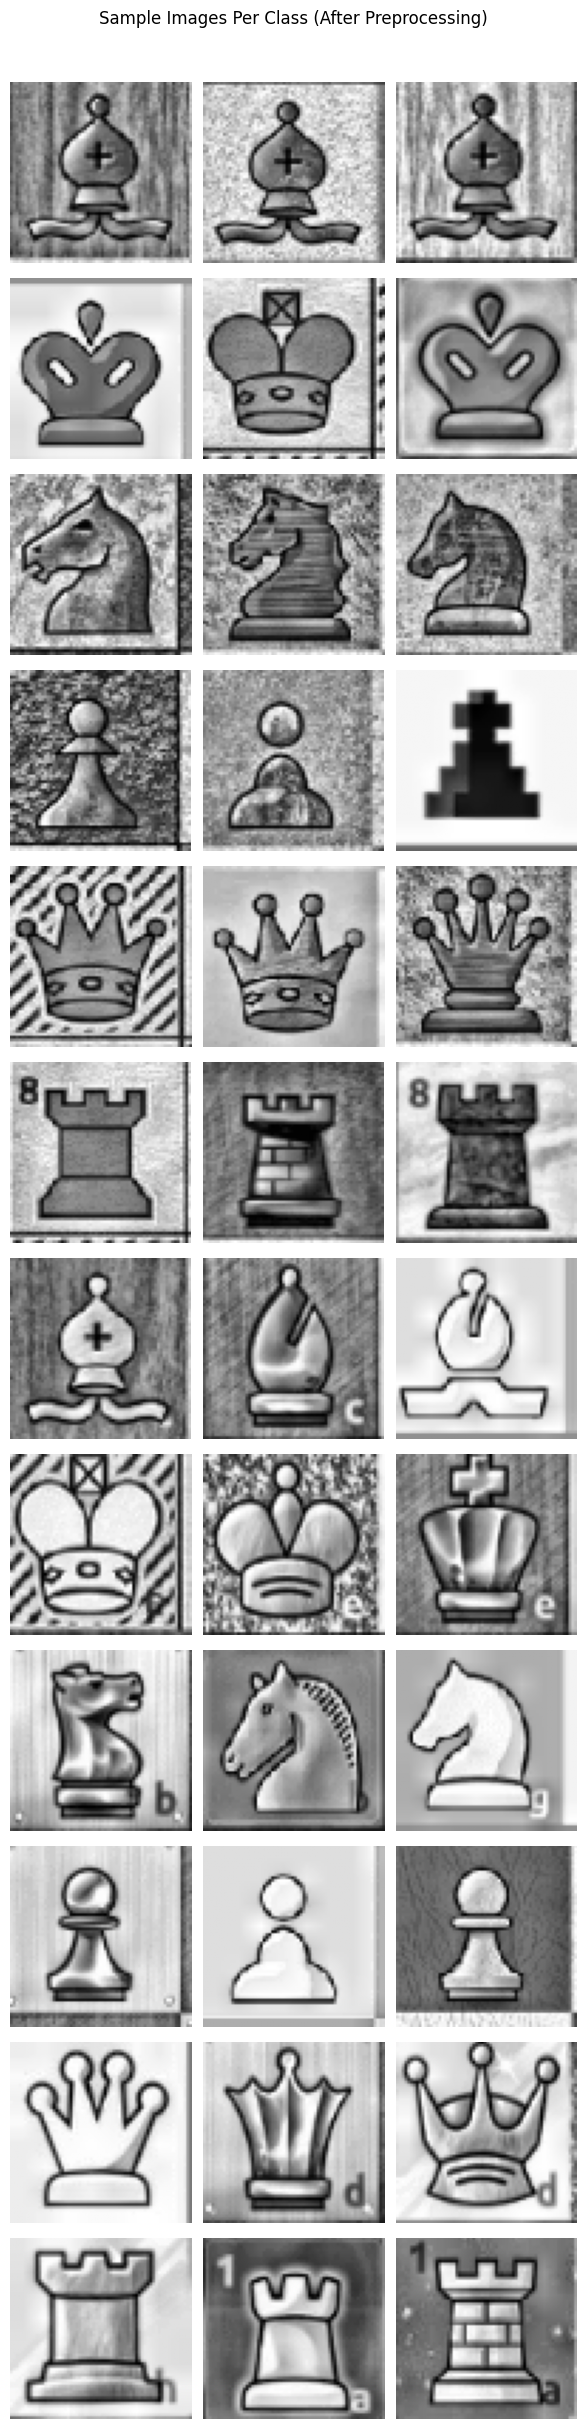

Saved sample_grid.png


In [4]:
# 2. Sample grid - 3 images per class
fig, axes = plt.subplots(12, 3, figsize=(6, 24))

for i, cls in enumerate(classes):
    cls_path = os.path.join(processed_dir, cls)
    images = os.listdir(cls_path)[:3]
    for j, img_name in enumerate(images):
        img = cv2.imread(os.path.join(cls_path, img_name),
                         cv2.IMREAD_GRAYSCALE)
        axes[i][j].imshow(img, cmap='gray')
        axes[i][j].axis('off')
        if j == 0:
            axes[i][j].set_ylabel(cls, fontsize=7, rotation=0,
                                  labelpad=50)

plt.suptitle("Sample Images Per Class (After Preprocessing)", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "sample_grid.png"), dpi=150)
plt.show()
print("Saved sample_grid.png")

# Feature Engineering & Dimensionality Reduction
Feature Engineering and Dimensionality Reduction for Chess Piece Classification

## 1. Import Required Libraries

In [18]:
import cv2
import numpy as np
import os
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns
import pickle

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Load Preprocessed Dataset

In [6]:
processed_dir = r"C:\Users\yadhu\Desktop\chess-piece\processed"

# Load all images and labels
X = []
y = []
labels_mapping = {}

classes = sorted(os.listdir(processed_dir))
print(f"Classes found: {classes}\n")

for idx, cls in enumerate(classes):
    labels_mapping[idx] = cls
    cls_path = os.path.join(processed_dir, cls)
    
    if not os.path.isdir(cls_path):
        continue
    
    image_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    for img_file in image_files:
        img_path = os.path.join(cls_path, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is not None:
            X.append(img)
            y.append(idx)
    
    print(f"Loaded {len(image_files)} images for class '{cls}'")

X = np.array(X)
y = np.array(y)

print(f"\n✓ Dataset loaded: {X.shape[0]} images, shape per image: {X.shape[1:]}")
print(f"✓ Number of classes: {len(np.unique(y))}")

Classes found: ['b_bishop', 'b_king', 'b_knight', 'b_pawn', 'b_queen', 'b_rook', 'w_bishop', 'w_king', 'w_knight', 'w_pawn', 'w_queen', 'w_rook']

Loaded 200 images for class 'b_bishop'
Loaded 200 images for class 'b_king'
Loaded 200 images for class 'b_knight'
Loaded 200 images for class 'b_pawn'
Loaded 200 images for class 'b_queen'
Loaded 200 images for class 'b_rook'
Loaded 200 images for class 'w_bishop'
Loaded 200 images for class 'w_king'
Loaded 200 images for class 'w_knight'
Loaded 200 images for class 'w_pawn'
Loaded 200 images for class 'w_queen'
Loaded 200 images for class 'w_rook'

✓ Dataset loaded: 2400 images, shape per image: (64, 64)
✓ Number of classes: 12


## 3. Feature Engineering
Create new numerical features from raw images such as intensity statistics, edge strength, and color category.

In [11]:
# Flatten images for feature extraction
X_flat = X.reshape(X.shape[0], -1)
print(f"Flattened shape: {X_flat.shape}")

# Statistical image features
mean_intensity = X_flat.mean(axis=1)
std_intensity = X_flat.std(axis=1)

# Edge strength via Sobel filter
sobel_x = np.array([[ -1, 0, 1], [ -2, 0, 2], [ -1, 0, 1]], dtype=np.float32)
sobel_y = sobel_x.T
edge_strength = []
for img in X:
    gx = cv2.filter2D(img.astype(np.float32), -1, sobel_x)
    gy = cv2.filter2D(img.astype(np.float32), -1, sobel_y)
    magnitude = np.sqrt(gx**2 + gy**2)
    edge_strength.append(magnitude.mean())
edge_strength = np.array(edge_strength)

# Derived categorical feature from brightness
color_feature = np.where(mean_intensity > 127, 'white', 'black')

feature_df = pd.DataFrame({
    'mean_intensity': mean_intensity,
    'std_intensity': std_intensity,
    'edge_strength': edge_strength,
    'color_category': color_feature,
})

feature_df.head(5)

Flattened shape: (2400, 4096)


,mean_intensity,std_intensity,edge_strength,color_category
0,119.795898,39.743499,173.329620,black
1,170.326416,58.306748,180.178268,white
2,149.255859,52.787142,190.214935,white
3,140.332764,43.973845,172.921982,white
4,180.029541,70.170373,171.030151,white


## 4. Encoding Categorical Values
Convert categorical values into numeric form using label encoding and one-hot encoding.

In [12]:
# Label encode the derived color category
color_encoder = LabelEncoder()
feature_df['color_label'] = color_encoder.fit_transform(feature_df['color_category'])
print('Color mapping:', dict(zip(color_encoder.classes_, color_encoder.transform(color_encoder.classes_))))

# One-hot encode the same categorical feature
color_onehot = pd.get_dummies(feature_df['color_category'], prefix='color')
print('\nOne-hot encoded columns:', list(color_onehot.columns))

feature_df = pd.concat([feature_df, color_onehot], axis=1)
feature_df.drop(columns=['color_category'], inplace=True)
feature_df.head(5)

Color mapping: {'black': np.int64(0), 'white': np.int64(1)}

One-hot encoded columns: ['color_black', 'color_white']


,mean_intensity,std_intensity,edge_strength,color_label,color_black,color_white
0,119.795898,39.743499,173.329620,0,True,False
1,170.326416,58.306748,180.178268,1,False,True
2,149.255859,52.787142,190.214935,1,False,True
3,140.332764,43.973845,172.921982,1,False,True
4,180.029541,70.170373,171.030151,1,False,True


## 5. Build Combined Feature Matrix
Merge flattened pixel features with engineered statistical features and apply scaling.

In [13]:
engineered_features = feature_df[['mean_intensity', 'std_intensity', 'edge_strength', 'color_label']].to_numpy()
X_combined = np.hstack([X_flat, engineered_features, color_onehot.to_numpy()])
print(f"Combined feature matrix shape: {X_combined.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)
print('Scaled combined feature matrix')

Combined feature matrix shape: (2400, 4102)
Scaled combined feature matrix


## 6. Dimensionality Reduction with PCA
Use PCA to reduce feature count while retaining 95% of variance.

PCA reduced shape: (2400, 304)
Components retained: 304


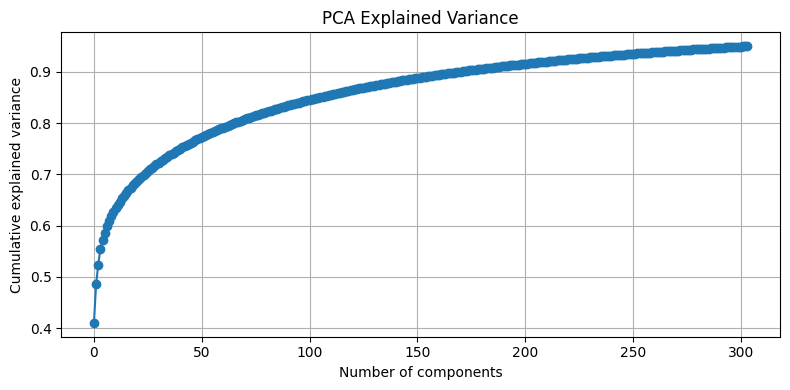

In [14]:
output_dir = Path(r"C:\Users\yadhu\Desktop\chess-piece\data")
output_dir.mkdir(parents=True, exist_ok=True)

pca = PCA(n_components=0.95, svd_solver='full', random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA reduced shape: {X_pca.shape}")
print(f"Components retained: {pca.n_components_}")

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.savefig(output_dir / 'pca_explained_variance.png', dpi=150)
plt.show()

## 7. Feature Selection and Importance
Rank features by ANOVA F-score and inspect the most important variables in sorted order.

In [15]:
selector = SelectKBest(score_func=f_classif, k=500)
X_selected = selector.fit_transform(X_scaled, y)

scores = selector.scores_
selected_mask = selector.get_support()

feature_names = [f'pixel_{i}' for i in range(X_flat.shape[1])] + [
    'mean_intensity', 'std_intensity', 'edge_strength', 'color_label'
] + list(color_onehot.columns)

sorted_index = np.argsort(scores)[::-1]
print('Top 20 features by ANOVA F-score:')
for rank, idx in enumerate(sorted_index[:20], start=1):
    print(f"{rank:2d}. {feature_names[idx]:<20} score={scores[idx]:.2f}")

print(f"\nSelected feature matrix shape: {X_selected.shape}")

Top 20 features by ANOVA F-score:
 1. pixel_2082           score=141.73
 2. pixel_2080           score=140.67
 3. pixel_2144           score=133.68
 4. pixel_2081           score=130.30
 5. pixel_2208           score=129.05
 6. pixel_2079           score=128.48
 7. pixel_2209           score=125.64
 8. pixel_2143           score=121.54
 9. pixel_2145           score=120.47
10. pixel_2272           score=119.17
11. pixel_2146           score=118.83
12. pixel_2083           score=118.59
13. pixel_2273           score=118.06
14. pixel_2207           score=115.45
15. pixel_2400           score=113.09
16. pixel_2591           score=112.47
17. pixel_2592           score=112.37
18. pixel_2527           score=112.34
19. pixel_2210           score=111.89
20. pixel_2336           score=111.45

Selected feature matrix shape: (2400, 500)


## 8. Persist Engineered Data and Transformers
Save the scaled matrix, PCA projection, selected features, and transformers for future modeling.

In [16]:
with open(output_dir / 'feature_data.pkl', 'wb') as f:
    pickle.dump({
        'X_scaled': X_scaled,
        'X_pca': X_pca,
        'X_selected': X_selected,
        'y': y,
        'labels_mapping': labels_mapping,
        'feature_df': feature_df,
    }, f)

with open(output_dir / 'feature_transformers.pkl', 'wb') as f:
    pickle.dump({
        'scaler': scaler,
        'pca': pca,
        'selector': selector,
        'color_encoder': color_encoder,
    }, f)

print('Saved feature_data.pkl and feature_transformers.pkl')

Saved feature_data.pkl and feature_transformers.pkl


## 9. Model Selection and Training
Train several candidate classifiers on the feature-engineered dataset and compare performance.

In [19]:
# Use the selected feature set for model training
X_model = X_selected

# Split dataset for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, stratify=y, random_state=42
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'SVC': SVC(kernel='rbf', probability=True, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1_score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'train_accuracy': model.score(X_train, y_train),
        'test_accuracy': accuracy_score(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred, zero_division=0),
    }
    print(f"\n{name} trained. Test accuracy: {results[name]['accuracy']:.4f}")

best_model_name = max(results, key=lambda k: results[k]['f1_score'])
best_model = results[best_model_name]['model']
print(f"\nBest model by weighted F1-score: {best_model_name}")


Logistic Regression trained. Test accuracy: 0.8646

Random Forest trained. Test accuracy: 0.8708

SVC trained. Test accuracy: 0.8438

Best model by weighted F1-score: Random Forest


## 10. Evaluation Results
Show accuracy, precision, recall, F1-score, and confusion matrix for each candidate model.

In [20]:
for name, stats in results.items():
    print(f"\n=== {name} ===")
    print(f"Train accuracy: {stats['train_accuracy']:.4f}")
    print(f"Test accuracy : {stats['test_accuracy']:.4f}")
    print(f"Precision    : {stats['precision']:.4f}")
    print(f"Recall       : {stats['recall']:.4f}")
    print(f"F1-score     : {stats['f1_score']:.4f}")
    print('\nClassification Report:')
    print(stats['classification_report'])
    print('Confusion Matrix:')
    print(stats['confusion_matrix'])

# Visual comparison dataframe
summary_df = pd.DataFrame([
    {
        'model': name,
        'train_accuracy': stats['train_accuracy'],
        'test_accuracy': stats['test_accuracy'],
        'precision': stats['precision'],
        'recall': stats['recall'],
        'f1_score': stats['f1_score'],
    }
    for name, stats in results.items()
])
summary_df = summary_df.sort_values(by='f1_score', ascending=False)
print('\nModel comparison:')
print(summary_df)


=== Logistic Regression ===
Train accuracy: 0.9964
Test accuracy : 0.8646
Precision    : 0.8668
Recall       : 0.8646
F1-score     : 0.8634

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.82      0.88        40
           1       0.93      0.97      0.95        40
           2       0.78      0.88      0.82        40
           3       0.75      0.82      0.79        40
           4       0.89      1.00      0.94        40
           5       0.82      0.82      0.82        40
           6       0.92      0.82      0.87        40
           7       0.95      0.95      0.95        40
           8       0.88      0.75      0.81        40
           9       0.81      0.72      0.76        40
          10       0.87      1.00      0.93        40
          11       0.86      0.80      0.83        40

    accuracy                           0.86       480
   macro avg       0.87      0.86      0.86       480
weighted avg       0.87

## 11. Overfitting / Underfitting Analysis
Check train vs test accuracy and identify potential overfitting or underfitting.

Logistic Regression: train/test gap=0.1318 → possible overfitting
Random Forest: train/test gap=0.1292 → possible overfitting
SVC: train/test gap=0.0766 → possible overfitting


<Figure size 800x500 with 0 Axes>

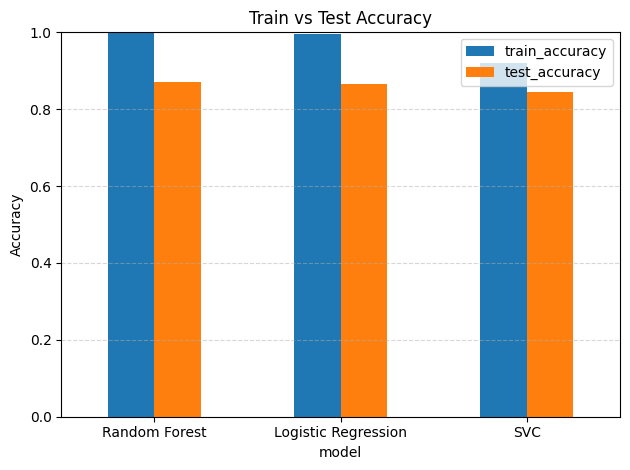

In [21]:
for name, stats in results.items():
    gap = stats['train_accuracy'] - stats['test_accuracy']
    status = 'balanced'
    if gap > 0.05:
        status = 'possible overfitting'
    elif gap < -0.05:
        status = 'possible underfitting'
    print(f"{name}: train/test gap={gap:.4f} → {status}")

plt.figure(figsize=(8, 5))
summary_df.plot(x='model', y=['train_accuracy', 'test_accuracy'], kind='bar', rot=0)
plt.title('Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 12. Save Final Model
Persist the best trained model and the feature pipeline for production use.

In [22]:
with open(output_dir / 'best_model.pkl', 'wb') as f:
    pickle.dump({
        'model_name': best_model_name,
        'model': best_model,
        'scaler': scaler,
        'selector': selector,
        'label_encoder': color_encoder,
        'labels_mapping': labels_mapping,
    }, f)

print(f"Saved best model: {best_model_name} to best_model.pkl")

Saved best model: Random Forest to best_model.pkl
